In [107]:
import numpy as np
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

In [108]:
#Define quat operators

def hat(v):
    v = np.asarray(v).reshape(3,)
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

def unhat(S):
    return 0.5 * np.array([S[2,1]-S[1,2],
                           S[0,2]-S[2,0],
                           S[1,0]-S[0,1]])

H = np.vstack([np.zeros((1,3)), np.eye(3)])
T = np.block([
    [np.array([[1]]), np.zeros((1,3))],
    [np.zeros((3,1)), -np.eye(3)]
])

def L(q):
    q = np.asarray(q)
    q0, qv = q[0], q[1:4]
    top = np.hstack([q0, -qv])
    bottom = np.hstack([qv.reshape(3,1), q0*np.eye(3) + hat(qv)])
    return np.vstack([top, bottom])

def R(q):
    q = np.asarray(q)
    return np.block([
        [q[0],            -q[1:4]],
        [q[1:4].reshape(3,1),  q[0]*np.eye(3) - hat(q[1:4])]
    ])

def G(q):
    return L(q) @ H

def Q(q):
    q0, q1, q2, q3 = q
    return np.array([
        [1-2*(q2**2+q3**2), 2*(q1*q2-q0*q3), 2*(q0*q2+q1*q3)],
        [2*(q1*q2+q0*q3), 1-2*(q1**2+q3**2), 2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2), 2*(q0*q1+q2*q3), 1-2*(q1**2+q2**2)]
    ])
    
def expq(phi):
    phi = np.asarray(phi)
    theta = np.linalg.norm(phi)
    if theta < 1e-8:
        return np.hstack([1.0, phi])
    return np.hstack([np.cos(theta), phi * np.sin(theta)/theta])


In [109]:
def dynamics(x):
    q = x[0:4] / np.linalg.norm(x[0:4])
    w = x[4:7]
    qdot = 0.5 * G(q) @ w
    wdot = -np.linalg.inv(J) @ (hat(w) @ J @ w)
    return np.hstack([qdot, wdot])

In [110]:
def rkstep(J, x, h):
    f1 = dynamics(x)
    f2 = dynamics(x + 0.5*h*f1)
    f3 = dynamics(x + 0.5*h*f2)
    f4 = dynamics(x + h*f3)
    xn = x + (h/6)*(f1 + 2*f2 + 2*f3 + f4)
    xn[0:4] /= np.linalg.norm(xn[0:4])
    return xn

In [111]:
J = np.diag([1, 1.25, 1.5])

In [112]:
h = 0.1 #time step
n = 600 #number of time steps
tf = n*h #final time

#sample random initial attitude
q0 = np.random.randn(4)
q0 = q0/np.linalg.norm(q0)

#sample random angular velocity
ω0 = 0.1*np.random.randn(3)

#sample random gyro bias
β0 = 0.3*np.random.randn(3)

x0 = np.hstack([q0, ω0])

In [113]:
xtraj = np.zeros((7, n))
xtraj[:,0] = x0
for k in range(n-1):
    xtraj[:,k+1] = rkstep(J, xtraj[:,k], h)

In [ ]:
# Noise
m = 4 #number of star trackers
W = 0.001*np.eye(3*m) #measurement noise
V = 0.001*np.eye(6) #process noise

In [115]:
# generate noisy gyro measurements
gyro = np.zeros((3, n))
for k in range(n):
    gyro[:,k] = xtraj[4:7,0] + β0 + sqrtm(V[3:6,3:6]) @ np.random.randn(3)

In [116]:
#Generate noisy star-tracker measurements
ytraj = np.zeros((4*m,n))
for k in range(n):
    qk = xtraj[0:4,k]
    wk = sqrtm(W) @ np.random.randn(3*m)
    wk = wk.reshape(3,m)
    yk = np.zeros((4,m))
    for l in range(m):
        yk[:,l] = L(qk) @ expq(wk[:,l])
    ytraj[:,k] = yk.flatten()

In [117]:
def state_prediction(x,u,h):
    q = x[0:4]
    beta = x[4:7]
    omega = u - beta
    delta_q = expq(0.5*h*omega)
    qn = L(q) @ delta_q
    qn /= np.linalg.norm(qn)
    return np.hstack([qn, beta])

def state_prediction_deriv(x,u,h):
    q = x[0:4]
    beta = x[4:7]
    omega = u - beta
    delta_q = expq(0.5*h*omega)
    qn = L(q) @ delta_q
    A = np.block([
        [G(qn).T @ R(delta_q) @ G(q), -0.5*h * (G(qn).T @ G(qn))],
        [np.zeros((3,3)), np.eye(3)]
    ])
    return A

In [118]:
def innovation(x,y):
    q = x[0:4]
    yk = y.reshape(4,m)
    zk = np.zeros((3,m))
    for k in range(m):
        zk[:,k] = G(q).T @ yk[:,k]
    return zk.flatten()

def innovation_deriv(x,y):
        q = x[0:4]
        yk = y.reshape(4,m)
        C = np.zeros((3*m,6))
        for k in range(m):
            C[3*k:3*k+3,0:3] = H.T @ R(yk[:,k]) @ T @ G(q)
        return C

In [119]:
# Filter Initialization
xfilt = np.zeros((7, n))
xfilt[0:4, 0] = q0 + 0.01*np.random.randn(4)
xfilt[0:4, 0] /= np.linalg.norm(xfilt[0:4, 0])
P = np.zeros((6, 6, n))
P[:,:,0] = 0.5*np.eye(6)

In [120]:
for k in range(n-1):
    # Prediction
    xpred = state_prediction(xfilt[:,k], gyro[:,k], h)
    A = state_prediction_deriv(xfilt[:,k], gyro[:,k], h)
    Ppred = A @ P[:,:,k] @ A.T + V

    # Innovation
    z = innovation(xpred, ytraj[:,k+1])
    C = innovation_deriv(xpred, ytraj[:,k+1])
    S = C @ Ppred @ C.T + W

    # Kalman gain
    K = Ppred @ C.T @ np.linalg.inv(S)

    # Update
    delta_x = -K @ z
    phi = delta_x[0:3]
    delta_q = np.hstack([np.sqrt(max(0, 1 - phi.T @ phi)), phi])
    xfilt[:,k+1] = np.hstack([L(xpred[0:4]) @ delta_q, xpred[4:7] + delta_x[3:6]])
    xfilt[0:4,k+1] /= np.linalg.norm(xfilt[0:4,k+1])
    P[:,:,k+1] = (np.eye(6) - K@C) @ Ppred @ (np.eye(6) - K@C).T + K @ W @ K.T

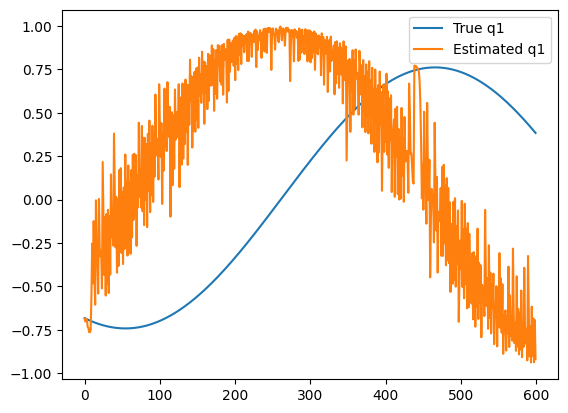

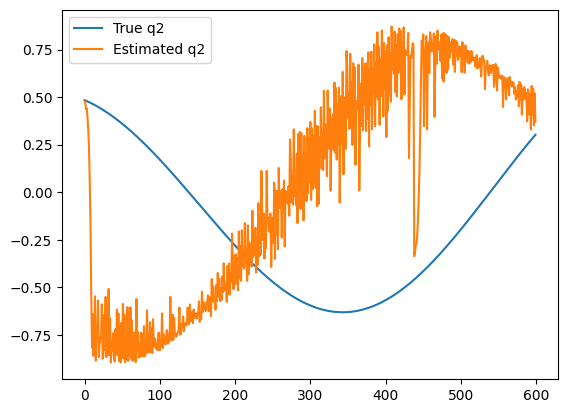

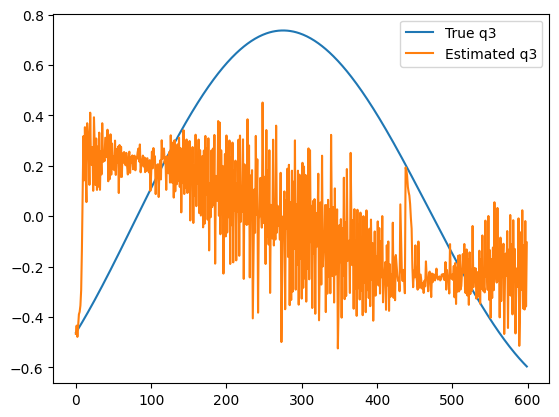

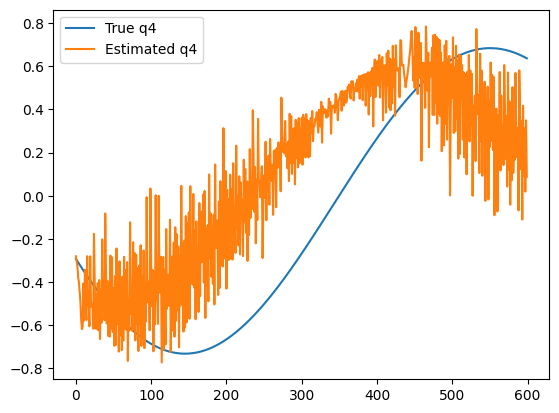

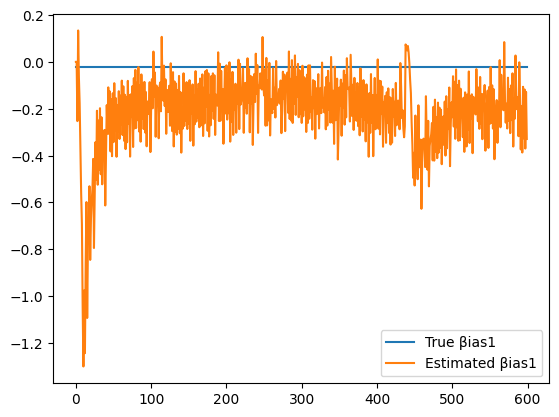

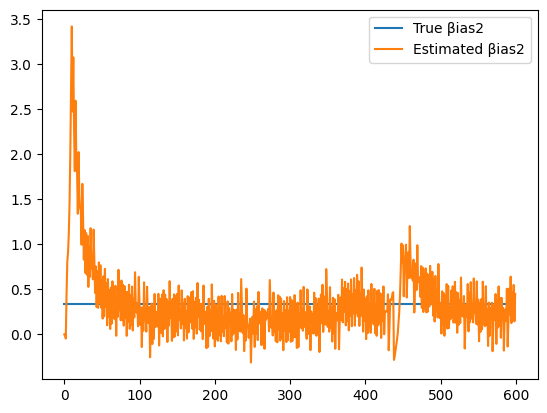

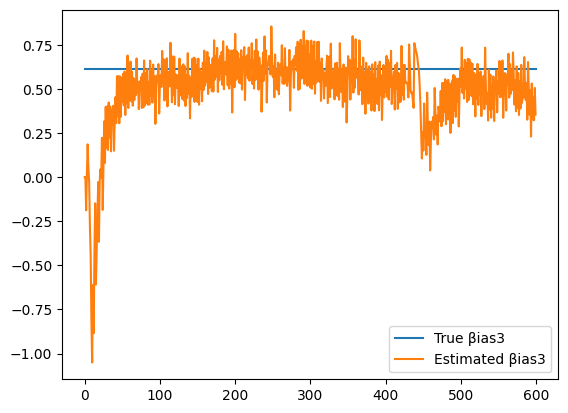

In [121]:
for i in range(4):
    plt.figure()
    plt.plot(xtraj[i,:], label=f'True q{i+1}')
    plt.plot(xfilt[i,:], label=f'Estimated q{i+1}')
    plt.legend()
    plt.show()

for i in range(3):
    plt.figure()
    plt.plot(β0[i]*np.ones(n), label=f'True βias{i+1}')
    plt.plot(xfilt[4+i,:], label=f'Estimated βias{i+1}')
    plt.legend()
    plt.show()